
# Overlay WCSim AmBe events into DAQ windows

This notebook builds synthetic acquisition windows of duration `deltat` by overlaying single-AmBe events from ROOT WCSim output. 

The true hits information is used.

## Model used here

For each recorded window:

1. define a continuous source stream with activity `A` and recorded live window length `deltat_seconds = deltat_ns * 1e-9`
2. draw the number of new source decays in the corresponding window from a Poisson law:
   - if `dead_time_ns = 0`:  
     `n ~ Poisson(A * deltat_seconds)`
   - if `dead_time_ns > 0`:  
     `n ~ Poisson(A * (deltat_ns + dead_time_ns) * 1e-9)`  
     because decays during the dead gap before the window are also generated
3. sample `n` events from the input ROOT file (without replacement)
4. for each sampled event:
   - draw one absolute prompt time uniformly in the generation interval
   - compute one global time shift that places that event in the continuous stream
   - keep the event as **active** until its latest relevant hit time has passed
5. for the current recorded window:
   - collect contributions from all active events
   - keep only hits and captures whose shifted absolute times fall inside the current recorded window
   - store times relative to the start of that window
6. merge and sort the surviving hits in time

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt

In [2]:
# ---------------------------
# Parameters
# ---------------------------

input_root = "../simulation/output/wcte_ambe_merged_hits.root"
tree_name = "TTrueHits"

# Source activity in Bq = decays / second
A = 3.7e6 * 0.01 # manually set to 1% of the nominal AmBe activity. Change as needed for testing.

# Acquisition window length in ns and s
deltat_ns = 270_000.0   # 270 microseconds
deltat_s = deltat_ns * 1e-9

# Number of synthetic acquisition windows to generate
N_windows = 100000

# Dead time between windows in ns
dead_time_ns = 7_750.0   # 7.75 microseconds

# RNG seed for reproducibility
seed = 12345
rng = np.random.default_rng(seed)

print(f"A = {A:.3f} Bq")
print(f"deltat = {deltat_ns:.1f} ns = {deltat_s:.6e} s")
print(f"Expected decays per window = A * deltat = {A * deltat_s:.6f}")
print(f"Dead time between windows = {dead_time_ns:.1f} ns = {dead_time_ns * 1e-9:.6e} s")

A = 37000.000 Bq
deltat = 270000.0 ns = 2.700000e-04 s
Expected decays per window = A * deltat = 9.990000
Dead time between windows = 7750.0 ns = 7.750000e-06 s


In [3]:

def poisson_n(activity_bq, deltat_seconds, rng):
    """Draw the number of source decays in one acquisition window."""
    lam = activity_bq * deltat_seconds
    return rng.poisson(lam)

# Quick check
[poisson_n(A, deltat_s, rng) for _ in range(10)]


[13, 9, 12, 11, 7, 8, 11, 10, 7, 8]

In [4]:
# ---------------------------
# Load the input event library
# ---------------------------
# Takes ~4 minutes to load 4M events

path = Path(input_root)
if not path.exists():
    raise FileNotFoundError(f"Input file not found: {path.resolve()}")

branches = [
    "event", "nsubevents", "subevent", "nhits", "ncaptures",
    "has_prompt", "prompt_track_id", "prompt_track_pdg",
    "prompt_track_energy", "prompt_track_time",
    "prompt_track_creator_process",
    "tubeid", "mPMTid", "mPMT_pmtid",
    "x", "y", "z", "dx", "dy", "dz",
    "truetime", "photon_end_energy",
    "creator_process", "hit_from_prompt", "hit_from_capture", "hit_from_otherprocess",
    "capture_t", "capture_x", "capture_y", "capture_z",
    "capture_nucleus", "capture_ngamma", "capture_total_gammaE"
]

with uproot.open(path) as f:
    tree = f[tree_name]
    arr = tree.arrays(branches, library="np")

n_library_events = len(arr["event"])
print(f"Loaded {n_library_events} library events from {input_root}:{tree_name}")

Loaded 4000000 library events from ../simulation/output/wcte_ambe_merged_hits.root:TTrueHits


## Build synthetic windows

The output is one pandas DataFrame row per window.

Each row stores variable-length NumPy arrays for the merged true-hit information in that window.

`make_window()` is a function that remembers things between calls:

- which window number it is currently generating
- which old events are still “alive” and may spill into the next window
- cached quantities computed once from the library

That remembered information is stored as attributes attached to the function itself:

- `make_window._state`

- `make_window._cache`

A helper function to clear the memory of the generator is needed: `def reset_make_window_stream()`

A helper function to inspect the state of the generator is defined: `get_make_window_status`

`hasattr(make_window, "_state")` checks whether the function already has a _state attribute.

`delattr(make_window, "_state")` deletes it if it exists.

The same is done for _cache.


This allows the generation of one window at a time while preserving a realistic source stream.

The shift operations are explicitly performed in float64. Otherwise, automatic casting to float32 can lead to a significant loss of precision when working with a very large number of windows, producing artifacts in the hit/capture times.

In [5]:
def reset_make_window_stream():
    """Reset the internal state of the continuous window generator."""
    if hasattr(make_window, "_state"):
        delattr(make_window, "_state")
    if hasattr(make_window, "_cache"):
        delattr(make_window, "_cache")


def get_make_window_status():
    """
    Inspect the internal state of make_window without modifying it.
    """
    status = {
        "initialized": hasattr(make_window, "_state"),
        "has_cache": hasattr(make_window, "_cache"),
    }

    if hasattr(make_window, "_state"):
        state = make_window._state
        status["window_idx"] = state.get("window_idx", None)
        status["n_active"] = len(state.get("active", []))

        if len(state.get("active", [])) > 0:
            abs_ends = np.array([ev["abs_end"] for ev in state["active"]], dtype=float)
            shifts = np.array([ev["shift"] for ev in state["active"]], dtype=float)

            status["active_abs_end_min"] = float(abs_ends.min())
            status["active_abs_end_max"] = float(abs_ends.max())
            status["active_shift_min"] = float(shifts.min())
            status["active_shift_max"] = float(shifts.max())
        else:
            status["active_abs_end_min"] = None
            status["active_abs_end_max"] = None
            status["active_shift_min"] = None
            status["active_shift_max"] = None

    if hasattr(make_window, "_cache"):
        cache = make_window._cache
        status["cache_library_id"] = cache.get("library_id", None)

        rel_end_time = cache.get("rel_end_time", None)
        if rel_end_time is not None:
            status["rel_end_time_min"] = float(np.min(rel_end_time))
            status["rel_end_time_max"] = float(np.max(rel_end_time))
            status["rel_end_time_p99"] = float(np.quantile(rel_end_time, 0.99))

    return status

def make_window(library, activity_bq, deltat_ns, rng, start_idx, gap_ns=0.0):
    """
    Build one synthetic acquisition window from a continuous source stream.

    This function supports two cases:

    1) gap_ns = 0:
       Recorded windows are back-to-back.
       This reproduces the behavior of the current implementation.

    2) gap_ns > 0:
       There is a dead gap between recorded windows.
       The source still emits during the gap, but no data are recorded there.
       Decays that start in the gap can still produce delayed captures/hits
       inside the next recorded window.

    Main ideas
    ----------
    - New source decays are generated as a Poisson process.
    - Each library event is consumed without replacement only when it STARTS.
    - Once started, that event stays "active" until its latest relevant time
      (late hit or capture) has passed.
    - Only hits/captures falling inside the CURRENT RECORDED window are kept.

    Parameters
    ----------
    library : dict of awkward arrays / numpy arrays
        Event library loaded from wcte_ambe_truehits.root
    activity_bq : float
        Source activity in Bq
    deltat_ns : float
        Live acquisition window length in ns
    rng : numpy.random.Generator
        Random number generator
    start_idx : int
        First unread library event to use for newly generated source decays
    gap_ns : float, optional
        Dead time between recorded windows, in ns.
        Default is 0.0, which gives the same behavior as the current code.

    Returns
    -------
    window_dict : dict
        Synthetic content of the current recorded window
    next_idx : int
        Next unread library index after consuming new decays introduced here
    """

    # ------------------------------------------------------------------
    # One-time cache:
    # For each library event, precompute
    #   1) the prompt relative time (for completness, but it's always 0 in the current library)
    #   2) the latest relative time at which the event can still contribute
    #
    # This avoids recomputing event lifetimes on every window.
    # ------------------------------------------------------------------
    n_events_available = len(library["event"])

    cache_valid = (
        hasattr(make_window, "_cache")
        and make_window._cache.get("library_id", None) == id(library)
    )

    if not cache_valid:
        rel_end_time = np.zeros(n_events_available, dtype=float)
        prompt_rel_time = np.zeros(n_events_available, dtype=float)

        for i in range(n_events_available):
            # Largest relevant relative time inside event i.
            max_rel = 0.0

            if len(library["truetime"][i]) > 0:
                hit_times_i = np.asarray(library["truetime"][i], dtype=float)
                valid_hit_times_i = hit_times_i[hit_times_i < 1e9] # this is introduced to don't carry forever the events with non-physical huge hit times

                if valid_hit_times_i.size > 0:
                    max_rel = max(max_rel, float(np.max(valid_hit_times_i)))

            if len(library["capture_t"][i]) > 0:
                cap_times_i = np.asarray(library["capture_t"][i], dtype=np.float64)
                max_rel = max(max_rel, float(np.max(cap_times_i))) # for completness, but capture time is expected to be always smaller than the last hit time 

            if int(library["has_prompt"][i]) == 1:
                prompt_rel_time[i] = float(library["prompt_track_time"][i])
                max_rel = max(max_rel, prompt_rel_time[i]) # for completness, but prompt_rel_time is always 0 

            rel_end_time[i] = max_rel

        make_window._cache = {
            "library_id": id(library),
            "rel_end_time": rel_end_time,
            "prompt_rel_time": prompt_rel_time,
        }

    rel_end_time = make_window._cache["rel_end_time"]
    prompt_rel_time = make_window._cache["prompt_rel_time"]

    # ------------------------------------------------------------------
    # Internal state of the continuous stream
    #
    # window_idx counts how many RECORDED windows have already been produced.
    # active stores events that started earlier and may still contribute now.
    # ------------------------------------------------------------------
    if not hasattr(make_window, "_state"):
        make_window._state = {
            "window_idx": 0,
            "active": [],   # each element: {"lib_idx", "shift", "abs_end"}
        }

    state = make_window._state
    window_idx = state["window_idx"]

    # ------------------------------------------------------------------
    # Absolute timing of the current RECORDED window
    #
    # For gap_ns = 0:
    #   t_start = window_idx * deltat_ns
    #   t_end   = t_start + deltat_ns
    #
    # For gap_ns > 0:
    #   recorded windows are separated by a dead gap
    #   stride = live window + dead gap
    # ------------------------------------------------------------------
    stride_ns = deltat_ns + gap_ns
    t_start = window_idx * stride_ns
    t_end = t_start + deltat_ns

    # ------------------------------------------------------------------
    # Time interval over which NEW source decays must be generated on this call
    #
    # If gap_ns = 0:
    #   gen interval = [t_start, t_end]
    #   which is exactly the same as the current implementation
    #
    # If gap_ns > 0:
    #   gen interval = [t_start - gap_ns, t_end]
    #   meaning:
    #     - decays during the dead gap before this window are generated now
    #     - decays during the current live window are also generated now
    #
    # This lets prompt-less delayed captures from the gap appear naturally
    # at the beginning of the recorded window.
    # ------------------------------------------------------------------
    gen_start = t_start - gap_ns
    gen_end = t_end
    gen_dt_ns = gen_end - gen_start
    gen_dt_s = gen_dt_ns * 1e-9

    n_overlay = rng.poisson(activity_bq * gen_dt_s)

    end_idx = start_idx + n_overlay
    if end_idx > n_events_available:
        raise ValueError(
            f"Not enough events left in library: requested {n_overlay} starting at {start_idx}, "
            f"but library size is {n_events_available}."
        )

    chosen = np.arange(start_idx, end_idx, dtype=np.int32)

    # ------------------------------------------------------------------
    # Add newly started events to the active list
    #
    # For each newly generated source decay:
    #   - choose its absolute prompt time uniformly in the generation interval
    #   - compute the shift between library-relative time and absolute time
    #   - compute the absolute end time of the event
    #
    # Later, only the pieces falling inside [t_start, t_end] are kept.
    # ------------------------------------------------------------------
    for lib_idx in chosen:
        prompt_abs_t = np.float64(rng.uniform(gen_start, gen_end))

        # General mapping:
        #   absolute_time = relative_time + shift
        shift = np.float64(prompt_abs_t - prompt_rel_time[lib_idx])

        # Latest absolute time at which this event can still contribute
        abs_end = np.float64(shift + rel_end_time[lib_idx])

        state["active"].append(
            {
                "lib_idx": int(lib_idx),
                "shift": float(shift),
                "abs_end": float(abs_end),
            }
        )

    # ------------------------------------------------------------------
    # Collect everything from active events that falls in the CURRENT
    # RECORDED window [t_start, t_end].
    # ------------------------------------------------------------------
    all_hit_t = []
    all_tubeid = []
    all_mPMTid = []
    all_mPMT_pmtid = []
    all_x = []
    all_y = []
    all_z = []
    all_dx = []
    all_dy = []
    all_dz = []
    all_photon_end_energy = []
    all_creator_process = []
    all_hit_from_prompt = []
    all_hit_from_capture = []
    all_source_event_idx = []
    all_source_event = []
    all_source_subevent = []

    all_capture_t = []
    all_relative_capture_t = []
    all_prompt_time_withcapture = []
    all_prompt_time = []
    all_capture_x = []
    all_capture_y = []
    all_capture_z = []
    all_capture_nucleus = []
    all_capture_ngamma = []
    all_capture_total_gammaE = []

    next_active = []

    for ev in state["active"]:
        lib_idx = ev["lib_idx"]
        shift = ev["shift"]
        abs_end = ev["abs_end"]

        # Keep event active for the NEXT call only if it can still contribute
        # after the end of the current recorded window.
        if abs_end > t_end:
            next_active.append(ev)

        # --------------------------------------------------------------
        # Hits in the current recorded window
        # --------------------------------------------------------------
        hit_rel_t = np.asarray(library["truetime"][lib_idx], dtype=np.float64)
        hit_abs_t = hit_rel_t + np.float64(shift)
        keep = (hit_abs_t >= t_start) & (hit_abs_t <= t_end)

        if np.any(keep):
            # Store hit times relative to the START of the recorded window
            all_hit_t.append(hit_abs_t[keep] - t_start)

            all_tubeid.append(library["tubeid"][lib_idx][keep])
            all_mPMTid.append(library["mPMTid"][lib_idx][keep])
            all_mPMT_pmtid.append(library["mPMT_pmtid"][lib_idx][keep])
            all_x.append(library["x"][lib_idx][keep])
            all_y.append(library["y"][lib_idx][keep])
            all_z.append(library["z"][lib_idx][keep])
            all_dx.append(library["dx"][lib_idx][keep])
            all_dy.append(library["dy"][lib_idx][keep])
            all_dz.append(library["dz"][lib_idx][keep])
            all_photon_end_energy.append(library["photon_end_energy"][lib_idx][keep])
            all_creator_process.append(library["creator_process"][lib_idx][keep])
            all_hit_from_prompt.append(library["hit_from_prompt"][lib_idx][keep])
            all_hit_from_capture.append(library["hit_from_capture"][lib_idx][keep])

            n_kept = int(np.count_nonzero(keep))
            all_source_event_idx.append(np.full(n_kept, lib_idx, dtype=np.int32))
            all_source_event.append(np.full(n_kept, library["event"][lib_idx], dtype=np.int32))
            all_source_subevent.append(np.full(n_kept, library["subevent"][lib_idx], dtype=np.int32))

        # --------------------------------------------------------------
        # Prompt truth in the current recorded window
        #
        # If the prompt happened in the gap or an earlier window, it is not
        # stored here, even if delayed capture products from the same event
        # are recorded now.
        # --------------------------------------------------------------
        if int(library["has_prompt"][lib_idx]) == 1:
            prompt_abs_t = np.float64(prompt_rel_time[lib_idx]) + np.float64(shift)
            prompt_keep_all = (prompt_abs_t >= t_start) and (prompt_abs_t <= t_end)

            if prompt_keep_all:
                all_prompt_time.append(np.array([prompt_abs_t - t_start], dtype=float))

        # --------------------------------------------------------------
        # Capture truth in the current recorded window
        # --------------------------------------------------------------
        if library["ncaptures"][lib_idx] > 0:
            cap_rel_t = np.asarray(library["capture_t"][lib_idx], dtype=np.float64)
            cap_abs_t = cap_rel_t + np.float64(shift)
            cap_keep = (cap_abs_t >= t_start) & (cap_abs_t <= t_end)

            if np.any(cap_keep):
                all_capture_t.append(cap_abs_t[cap_keep] - t_start)
                all_relative_capture_t.append(library["capture_t"][lib_idx][cap_keep])

                # For prompt_time_withcapture, only store the prompt if that
                # prompt itself is also inside the recorded window.
                if int(library["has_prompt"][lib_idx]) == 1:
                    prompt_abs_t = np.float64(prompt_rel_time[lib_idx]) + np.float64(shift)
                    prompt_keep = (
                        (prompt_abs_t >= t_start)
                        and (prompt_abs_t <= t_end)
                        and np.all(prompt_rel_time[lib_idx] < library["capture_t"][lib_idx][cap_keep])
                    )

                    if prompt_keep:
                        all_prompt_time_withcapture.append(
                            np.full(np.count_nonzero(cap_keep), prompt_abs_t - t_start, dtype=float)
                        )

                all_capture_x.append(library["capture_x"][lib_idx][cap_keep])
                all_capture_y.append(library["capture_y"][lib_idx][cap_keep])
                all_capture_z.append(library["capture_z"][lib_idx][cap_keep])
                all_capture_nucleus.append(library["capture_nucleus"][lib_idx][cap_keep])
                all_capture_ngamma.append(library["capture_ngamma"][lib_idx][cap_keep])
                all_capture_total_gammaE.append(library["capture_total_gammaE"][lib_idx][cap_keep])

    # ------------------------------------------------------------------
    # Update the stream state for the next call
    # ------------------------------------------------------------------
    state["active"] = next_active
    state["window_idx"] += 1

    # ------------------------------------------------------------------
    # Helper to concatenate per-event contributions into one window array
    # ------------------------------------------------------------------
    def _cat(lst, dtype):
        if not lst:
            return np.array([], dtype=dtype)
        return np.concatenate(lst).astype(dtype, copy=False)

    hit_t = _cat(all_hit_t, float)
    tubeid = _cat(all_tubeid, np.int32)
    mPMTid = _cat(all_mPMTid, np.int32)
    mPMT_pmtid = _cat(all_mPMT_pmtid, np.int32)
    x = _cat(all_x, np.float32)
    y = _cat(all_y, np.float32)
    z = _cat(all_z, np.float32)
    dx = _cat(all_dx, np.float32)
    dy = _cat(all_dy, np.float32)
    dz = _cat(all_dz, np.float32)
    photon_end_energy = _cat(all_photon_end_energy, np.float32)
    creator_process = _cat(all_creator_process, np.int32)
    hit_from_prompt = _cat(all_hit_from_prompt, np.int32)
    hit_from_capture = _cat(all_hit_from_capture, np.int32)
    source_event_idx = _cat(all_source_event_idx, np.int32)
    source_event = _cat(all_source_event, np.int32)
    source_subevent = _cat(all_source_subevent, np.int32)

    capture_t = _cat(all_capture_t, float)
    relative_capture_t = _cat(all_relative_capture_t, float)
    prompt_time_withcapture = _cat(all_prompt_time_withcapture, float)
    prompt_time = _cat(all_prompt_time, float)
    capture_x = _cat(all_capture_x, np.float32)
    capture_y = _cat(all_capture_y, np.float32)
    capture_z = _cat(all_capture_z, np.float32)
    capture_nucleus = _cat(all_capture_nucleus, np.int32)
    capture_ngamma = _cat(all_capture_ngamma, np.int32)
    capture_total_gammaE = _cat(all_capture_total_gammaE, np.float32)

    # ------------------------------------------------------------------
    # Sort hit-level arrays by hit time inside the recorded window
    # ------------------------------------------------------------------
    if hit_t.size > 0:
        order = np.argsort(hit_t, kind="stable")
        hit_t = hit_t[order]
        tubeid = tubeid[order]
        mPMTid = mPMTid[order]
        mPMT_pmtid = mPMT_pmtid[order]
        x = x[order]
        y = y[order]
        z = z[order]
        dx = dx[order]
        dy = dy[order]
        dz = dz[order]
        photon_end_energy = photon_end_energy[order]
        creator_process = creator_process[order]
        hit_from_prompt = hit_from_prompt[order]
        hit_from_capture = hit_from_capture[order]
        source_event_idx = source_event_idx[order]
        source_event = source_event[order]
        source_subevent = source_subevent[order]

    return {
        # Number of NEW library events introduced on this call.
        # For gap_ns = 0, this means new decays started in the current window.
        # For gap_ns > 0, this means new decays started in the interval
        # [t_start - gap_ns, t_end].
        "n_overlay": int(n_overlay),

        "window_sum_photon_end_energy": float(photon_end_energy.sum()) if photon_end_energy.size else 0.0,
        "n_hits": int(hit_t.size),
        "hit_t": hit_t,
        "tubeid": tubeid,
        "mPMTid": mPMTid,
        "mPMT_pmtid": mPMT_pmtid,
        "x": x,
        "y": y,
        "z": z,
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "photon_end_energy": photon_end_energy,
        "creator_process": creator_process,
        "hit_from_prompt": hit_from_prompt,
        "hit_from_capture": hit_from_capture,
        "source_event_idx": source_event_idx,
        "source_event": source_event,
        "source_subevent": source_subevent,
        "capture_t": capture_t,
        "relative_capture_t": relative_capture_t,
        "prompt_time_withcapture": prompt_time_withcapture,
        "prompt_time": prompt_time,
        "capture_x": capture_x,
        "capture_y": capture_y,
        "capture_z": capture_z,
        "capture_nucleus": capture_nucleus,
        "capture_ngamma": capture_ngamma,
        "capture_total_gammaE": capture_total_gammaE,
    }, end_idx

In [6]:
# Generate many synthetic windows from one continuous run
# and throw away the first 5 warmup windows

reset_make_window_stream()

warmup_windows = 5
windows = []
next_idx = 0

for i in range(N_windows + warmup_windows):
    w, next_idx = make_window(arr, A, deltat_ns, rng, start_idx=next_idx, gap_ns=dead_time_ns)

    # Discard the first warmup_windows windows to warm up the left edge
    if i < warmup_windows:
        continue

    kept_i = i - warmup_windows
    w["window_id"] = kept_i
    windows.append(w)

    if (kept_i + 1) % 1000 == 0:
        print(f"Generated {kept_i + 1} / {N_windows} windows...")
        
        s = get_make_window_status()
        print(
            f"{i+1} windows | "
            f"window_idx={s.get('window_idx')} | "
            f"n_active={s.get('n_active')} | "
            #f"rel_end_time_max={s.get('rel_end_time_max')}"
        )

Generated 1000 / 100000 windows...
1005 windows | window_idx=1005 | n_active=1 | 
Generated 2000 / 100000 windows...
2005 windows | window_idx=2005 | n_active=4 | 
Generated 3000 / 100000 windows...
3005 windows | window_idx=3005 | n_active=2 | 
Generated 4000 / 100000 windows...
4005 windows | window_idx=4005 | n_active=5 | 
Generated 5000 / 100000 windows...
5005 windows | window_idx=5005 | n_active=1 | 
Generated 6000 / 100000 windows...
6005 windows | window_idx=6005 | n_active=4 | 
Generated 7000 / 100000 windows...
7005 windows | window_idx=7005 | n_active=3 | 
Generated 8000 / 100000 windows...
8005 windows | window_idx=8005 | n_active=6 | 
Generated 9000 / 100000 windows...
9005 windows | window_idx=9005 | n_active=5 | 
Generated 10000 / 100000 windows...
10005 windows | window_idx=10005 | n_active=4 | 
Generated 11000 / 100000 windows...
11005 windows | window_idx=11005 | n_active=5 | 
Generated 12000 / 100000 windows...
12005 windows | window_idx=12005 | n_active=4 | 
Generat

In [7]:
windows_df = pd.DataFrame(windows)
pd.set_option('display.max_columns', None)
windows_df.head()

,n_overlay,window_sum_photon_end_energy,n_hits,hit_t,tubeid,mPMTid,mPMT_pmtid,x,y,z,dx,dy,dz,photon_end_energy,creator_process,hit_from_prompt,hit_from_capture,source_event_idx,source_event,source_subevent,capture_t,relative_capture_t,prompt_time_withcapture,prompt_time,capture_x,capture_y,capture_z,capture_nucleus,capture_ngamma,capture_total_gammaE,window_id
0,8,0.002530,869,"[1826.0501768235117, 1826.1326131105889, 1826....","[505, 461, 505, 181, 172, 163, 177, 966, 975, ...","[64, 62, 64, 47, 47, 46, 47, 5, 6, 46, 18, 23,...","[11, 5, 11, 10, 1, 11, 6, 16, 6, 3, 10, 5, 14,...","[-144.98727, -66.45533, -144.98727, -105.42974...","[31.189617, 15.52375, 31.189617, -28.909212, -...","[-60.0557, -138.39581, -60.0557, -116.50718, -...","[0.75387394, 0.07611865, 0.75387394, 0.7813687...","[0.57806987, 1.2289107e-16, 0.57806987, 0.5006...","[0.31226483, 0.99709874, 0.31226483, 0.3726115...","[2.440748e-06, 2.6973348e-06, 3.7072964e-06, 2...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 5...","[54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5474.890224132454, 83437.38224694831, 9824.60...","[47208.65625, 124408.9609375, 36064.75390625, ...",[41581.76257780031],"[41581.76257780031, 38313.30433801212, 235823....","[-10.178891, 4.5395684, 5.9519043, -3.7716658,...","[30.4751, 30.218958, 12.337414, 30.770836, 26....","[4.696885, -25.911903, -9.435396, 3.863261, 2....","[1000010020, 1000641580, 1000641560, 100001002...","[1, 5, 4, 1, 6, 3, 3, 1, 1, 4]","[2.2243783, 7.8699994, 8.459999, 2.2243674, 8....",0
1,11,0.004092,1402,"[25655.295299476245, 25655.341669558315, 25655...","[574, 577, 525, 528, 548, 573, 1469, 532, 522,...","[68, 68, 65, 65, 66, 68, 83, 65, 65, 84, 81, 5...","[4, 7, 12, 15, 16, 3, 6, 19, 9, 3, 16, 9, 2, 2...","[-54.766037, -62.5589, -156.86691, -156.86691,...","[22.828617, 8.2188835, 28.910713, 7.7947826, 2...","[143.23767, 140.00977, 7.728967, 13.386964, 67...","[0.50745314, 0.21989681, 0.8159873, 0.8159873,...","[0.26954928, -0.26954928, 0.50062317, -0.28903...","[-0.8184342, -0.9375439, 0.28903493, 0.5006231...","[2.9833836e-06, 2.9772189e-06, 2.5430404e-06, ...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 6...","[69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 69, 6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[49992.97562057362, 45736.77308801212, 64782.7...","[186261.59375, 285173.46875, 106708.8125, 2149...","[25648.484439409338, 124217.67546182219, 32000...","[185527.0253792992, 25648.484439409338, 202845...","[-22.76451, -1.3653181, -8.694708, -1.7828536,...","[14.538668, 19.298223, 33.21821, 28.32449, 35....","[10.477371, -20.217255, 3.1798608, 6.5133834, ...","[1000010020, 1000010020, 1000641580, 100001002...","[1, 1, 3, 1, 4, 1, 4, 3, 1, 1, 4, 1]","[2.2243743, 2.2243795, 7.87, 2.2243743, 8.4599...",1
2,11,0.004817,1668,"[978.4146308847703, 979.1216670491267, 983.507...","[1384, 1371, 1670, 776, 481, 1747, 1655, 1641,...","[76, 76, 95, 31, 63, 100, 95, 94, 63, 41, 14, ...","[16, 3, 17, 16, 6, 18, 2, 7, 6, 19, 17, 19, 19...","[52.889732, 62.500343, 58.0, -116.38686, -111....","[60.136787, 80.73166, 138.78236, -113.86321, 8...","[-147.88388, -140.01468, 100.54207, -105.45645...","[-0.57929826, -0.21989681, 3.539657e-17, 0.372...","[-0.50062317, 0.26954928, -0.8159873, -0.50062...","[0.64326507, 0.9375439, -0.57806987, 0.7813687...","[2.2721722e-06, 2.9169225e-06, 3.0883589e-06, ...","[6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 8...","[83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 8...","[

In [8]:
# Summary
print(f"Total number of events used: {windows_df['n_overlay'].sum()} / {n_library_events}")

summary = windows_df[["n_overlay", "n_hits", "window_sum_photon_end_energy"]].copy()
summary.describe()

Total number of events used: 1026715 / 4000000


,n_overlay,n_hits,window_sum_photon_end_energy
count,100000.000000,100000.000000,100000.000000
mean,10.267150,1590.096030,0.004571
std,3.202946,736.662088,0.002080
min,0.000000,0.000000,0.000000
25%,8.000000,1050.000000,0.003048
50%,10.000000,1498.000000,0.004315
75%,12.000000,2029.000000,0.005813
max,27.000000,6433.000000,0.018241


In [9]:
# Inspect one synthetic window
k = 5
row = windows_df.iloc[k]

print(f"window_id = {row['window_id']}")
print(f"n_overlay = {row['n_overlay']}")
print(f"n_hits = {row['n_hits']}")
print(f"window_sum_photon_end_energy = {row['window_sum_photon_end_energy']:.3f}")
print(f"prompt times [ns] = {row['prompt_time']}")
print("absolute capture_t [ns] =", row["capture_t"])
print("capture time from prompt (relative) [ns] =", row["relative_capture_t"])

print("True-hit times [ns] =", row["hit_t"])
print("Photon end energies [MeV] =", row["photon_end_energy"])
print("Is from prompt =", row["hit_from_prompt"])
print(f"Len of capture_t = {len(row['capture_t'])}")

# mask = (row["hit_t"] > 250_000) & (row["hit_t"] < 255_000) # for debugging
#print("True-hit times [ns] =", *row["hit_t"][mask])
#print("Photon end energies [MeV] =", *row["photon_end_energy"][mask])
#print("Is from prompt =", *row["hit_from_prompt"][mask])

window_id = 5
n_overlay = 15
n_hits = 2232
window_sum_photon_end_energy = 0.006
prompt times [ns] = [173306.30747332 255927.21090778  45019.09717389 231956.50248414
  84997.37218322 182907.5385968  119834.11798535]
absolute capture_t [ns] = [ 43838.02074846  70624.06653138   3000.69873695  88613.1379939
 258546.52512059 233489.16294207 258029.58908161 238069.60286734
 212734.78281532 234171.25342389 228290.31133125 268258.46732789
 123359.95030822 211105.73586242 179804.91060224 215832.69611035]
capture time from prompt (relative) [ns] = [ 77868.4296875  115399.1796875   61385.4140625   16409.11914062
  32371.41992188  60182.85546875   2102.37817383  16162.46386719
  33095.75       189152.15625    176731.46875     36301.96484375
  38362.578125    28198.19726562  66629.3046875   95998.578125  ]
True-hit times [ns] = [  3006.03249611   3006.44341208   3006.58364083 ... 268267.90277161
 268267.99751051 268281.1224926 ]
Photon end energies [MeV] = [2.6033597e-06 2.7181143e-06 3.2372097e-06

In [10]:
# Flatten one synthetic window into a per-hit table
k = 0
row = windows_df.iloc[k]

hits_df = pd.DataFrame({
    "tubeid": row["tubeid"],
    "mPMTid": row["mPMTid"],
    "mPMT_pmtid": row["mPMT_pmtid"],
    "x": row["x"],
    "y": row["y"],
    "z": row["z"],
    "dx": row["dx"],
    "dy": row["dy"],
    "dz": row["dz"],

    "hit_t": row["hit_t"],
    "photon_end_energy": row["photon_end_energy"],
    "creator_process": row["creator_process"],
    "hit_from_prompt": row["hit_from_prompt"],
    "hit_from_capture": row["hit_from_capture"],
    "source_event_idx": row["source_event_idx"],
})

hits_df.head(10)

,tubeid,mPMTid,mPMT_pmtid,x,y,z,dx,dy,dz,hit_t,photon_end_energy,creator_process,hit_from_prompt,hit_from_capture,source_event_idx
0,505,64,11,-144.987274,31.189617,-60.055698,0.753874,5.780699e-01,0.312265,1826.050177,0.000002,6,0,1,54
1,461,62,5,-66.455330,15.523750,-138.395813,0.076119,1.228911e-16,0.997099,1826.132613,0.000003,6,0,1,54
2,505,64,11,-144.987274,31.189617,-60.055698,0.753874,5.780699e-01,0.312265,1826.370330,0.000004,6,0,1,54
3,181,47,10,-105.429741,-28.909212,-116.507179,0.781369,5.006232e-01,0.372612,1826.573734,0.000003,6,0,1,54
4,172,47,1,-107.442261,-42.476250,-107.442261,0.707107,8.659561e-17,0.707107,1826.610879,0.000002,6,0,1,54
5,163,46,11,-60.030369,-27.018316,-144.926132,0.312265,5.780699e-01,0.753874,1826.821611,0.000004,6,0,1,54
6,177,47,6,-111.376305,-49.781116,-105.411903,0.561941,-2.695493e-01,0.782027,1826.977810,0.000003,6,0,1,54
7,966,5,16,-7.728967,-138.782364,-44.613037,-0.289035,8.159873e-01,0.500623,1827.001055,0.000003,6,0,1,54
8,975,6,6,-62.161488,-135.190002,-50.792091,-0.155624,9.503285e-01,0.269549,1827.396933,0.000003,6,0,1,54
9,155,46,3,-54.810917,-35.268341,-143.199753,0.507453,2.695493e-01,0.818434,1827.925943,0.000003,6,0,1,54



## Notes

- In this true-hit version there is no per-hit digitized charge `q`. The notebook uses `photon_end_energy` instead.

# Descriptive plots

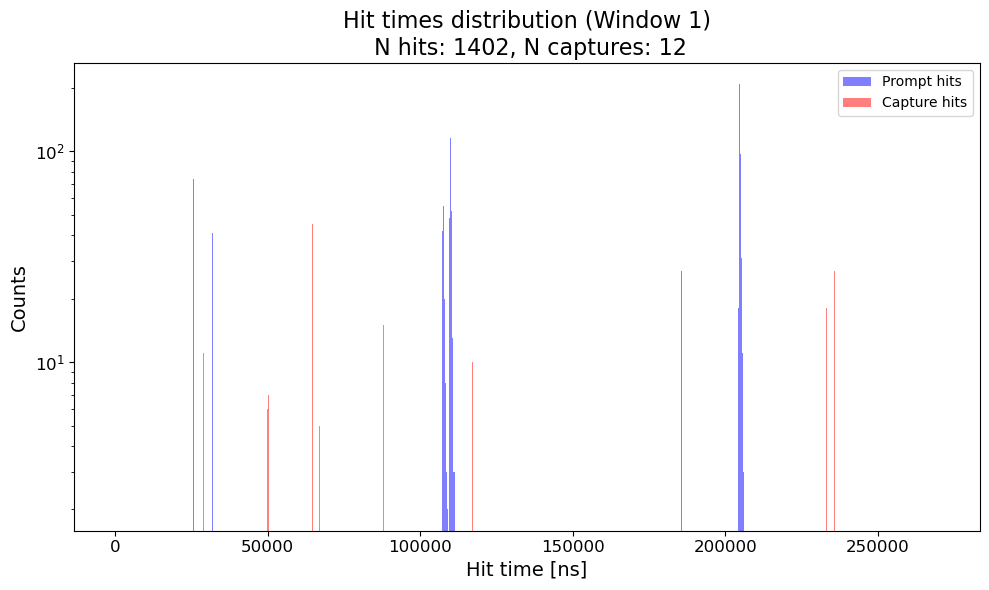

In [11]:
window_idx = 1
w = windows[window_idx]

mask_prompts = w["hit_from_prompt"] == 1
mask_captures = w["hit_from_capture"] == 1
prompt_times = w["hit_t"][mask_prompts]
capture_times = w["hit_t"][mask_captures]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(prompt_times, bins=np.linspace(0,270_000,1000), alpha=0.5, color="blue", label="Prompt hits")
ax.hist(capture_times, bins=np.linspace(0,270_000,1000), alpha=0.5, color="red", label="Capture hits")
ax.set_xlabel("Hit time [ns]", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.set_yscale("log")
ax.set_title(f"Hit times distribution (Window {window_idx})\n N hits: {len(w['hit_t'])}, N captures: {len(w['capture_t'])}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend()
plt.tight_layout()
plt.show()

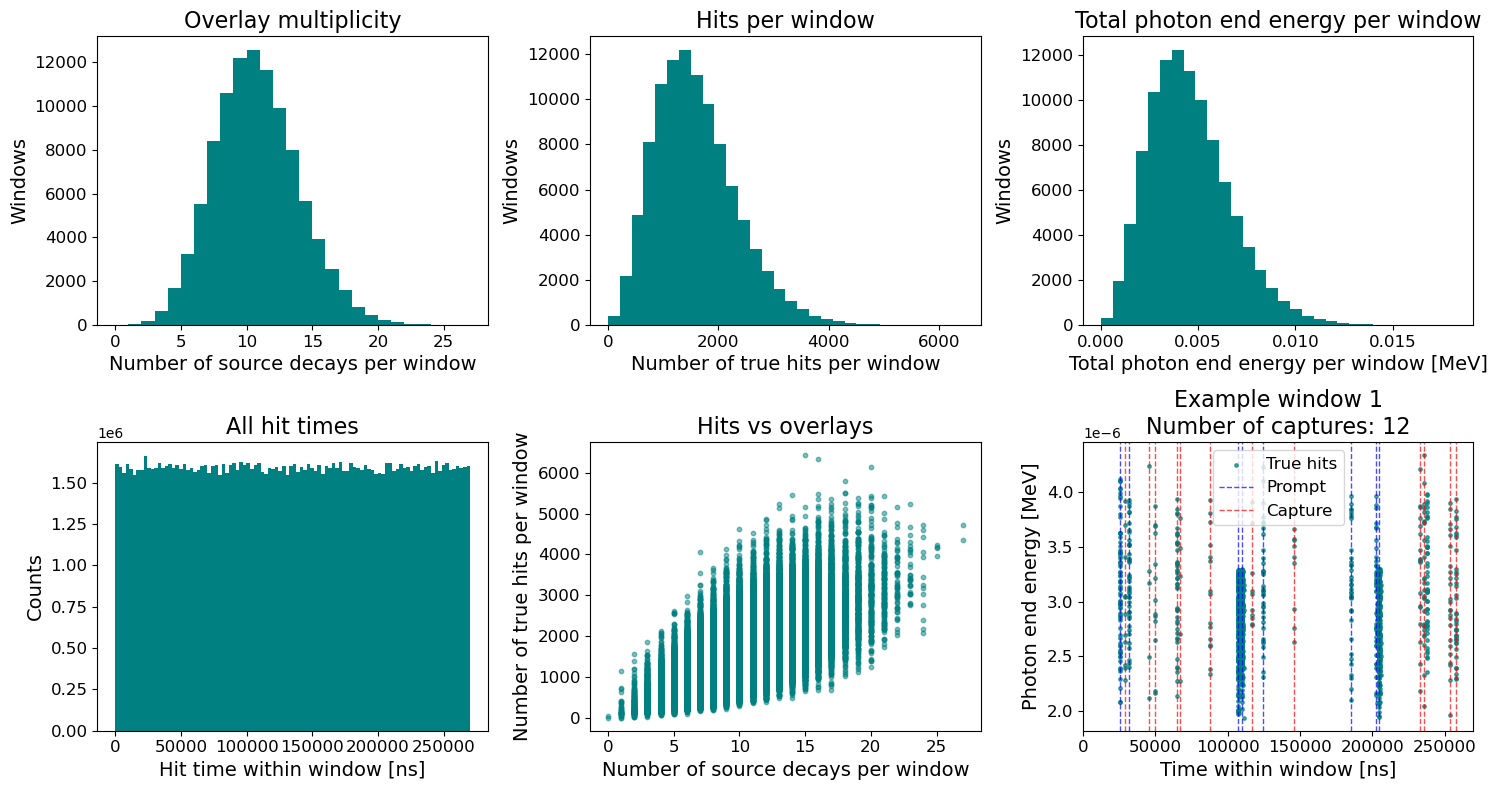

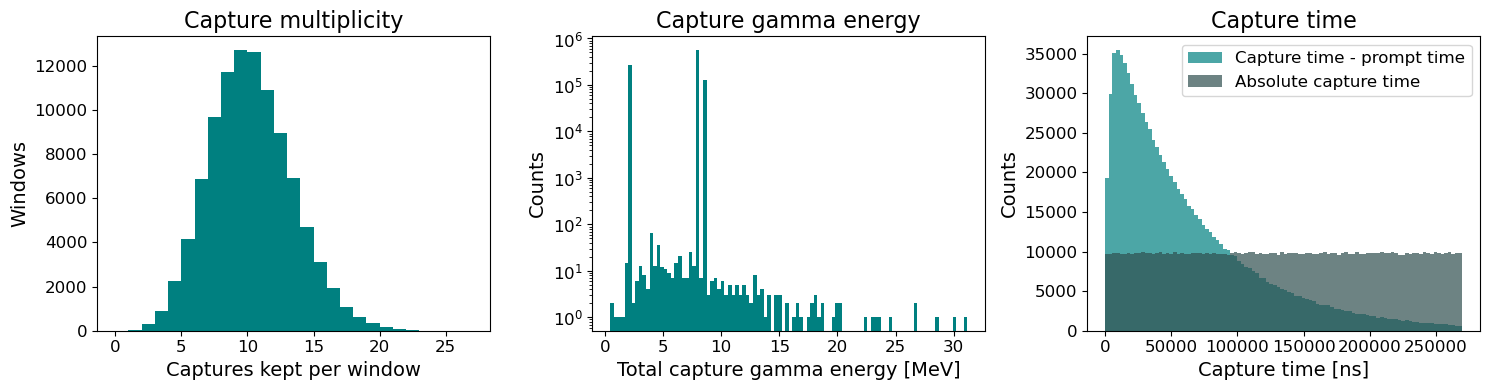

In [12]:
# Build flattened arrays
all_hit_t = np.concatenate([w for w in windows_df["hit_t"] if len(w) > 0]) if len(windows_df) else np.array([])
all_photon_end_energy = np.concatenate([w for w in windows_df["photon_end_energy"] if len(w) > 0]) if len(windows_df) else np.array([])
all_capture_t = np.concatenate([w for w in windows_df["capture_t"] if len(w) > 0]) if len(windows_df) else np.array([])
all_relative_capture_t = np.concatenate([w for w in windows_df["relative_capture_t"] if len(w) > 0]) if len(windows_df) else np.array([])
all_prompt_time = np.concatenate([w for w in windows_df["prompt_time"] if len(w) > 0]) if len(windows_df) else np.array([])
all_capture_total_gammaE = np.concatenate([w for w in windows_df["capture_total_gammaE"] if len(w) > 0]) if len(windows_df) else np.array([])

# Number of captures kept per window
n_captures_kept = windows_df["capture_t"].apply(len).to_numpy()

# Choose one example window to visualize in time
window_idx = 1
w = windows[window_idx]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1) Overlay multiplicity
axes[0, 0].hist(
    windows_df["n_overlay"],
    bins=np.arange(0, np.max(windows_df["n_overlay"]) + 1),
    color="teal"
)
axes[0, 0].set_xlabel("Number of source decays per window", fontsize=14)
axes[0, 0].set_ylabel("Windows", fontsize=14)
axes[0, 0].set_title("Overlay multiplicity", fontsize=16)
axes[0, 0].tick_params(axis="both", labelsize=12)

# 2) Hits per window
axes[0, 1].hist(windows_df["n_hits"], bins=30, color="teal")
axes[0, 1].set_xlabel("Number of true hits per window", fontsize=14)
axes[0, 1].set_ylabel("Windows", fontsize=14)
axes[0, 1].set_title("Hits per window", fontsize=16)
axes[0, 1].tick_params(axis="both", labelsize=12)

# 3) Total photon end energy per window
axes[0, 2].hist(windows_df["window_sum_photon_end_energy"], bins=30, color="teal")
axes[0, 2].set_xlabel("Total photon end energy per window [MeV]", fontsize=14)
axes[0, 2].set_ylabel("Windows", fontsize=14)
axes[0, 2].set_title("Total photon end energy per window", fontsize=16)
axes[0, 2].tick_params(axis="both", labelsize=12)

# 4) All hit times
axes[1, 0].hist(all_hit_t, bins=100, range=(0, deltat_ns), color="teal")
axes[1, 0].set_xlabel("Hit time within window [ns]", fontsize=14)
axes[1, 0].set_ylabel("Counts", fontsize=14)
axes[1, 0].set_title("All hit times", fontsize=16)
axes[1, 0].tick_params(axis="both", labelsize=12)

# 5) Hits vs overlays
axes[1, 1].scatter(
    windows_df["n_overlay"],
    windows_df["n_hits"],
    color="teal",
    s=10,
    alpha=0.5
)
axes[1, 1].set_xlabel("Number of source decays per window", fontsize=14)
axes[1, 1].set_ylabel("Number of true hits per window", fontsize=14)
axes[1, 1].set_title("Hits vs overlays", fontsize=16)
axes[1, 1].tick_params(axis="both", labelsize=12)

# 6) Example window: photon end energy vs time with capture markers
prompt_times = w["prompt_time"]
axes[1, 2].scatter(
    w["hit_t"],
    w["photon_end_energy"],
    s=6,
    alpha=0.7,
    label="True hits",
    color="teal"
)
for tc in prompt_times:
    axes[1, 2].axvline(
        tc,
        linestyle="--",
        linewidth=1,
        label="Prompt" if tc == prompt_times[0] else None,
        color="blue",
        alpha=0.7
    )
for tc in w["capture_t"]:
    axes[1, 2].axvline(
        tc,
        linestyle="--",
        linewidth=1,
        label="Capture" if tc == w["capture_t"][0] else None,
        color="red",
        alpha=0.7
    )
axes[1, 2].set_xlabel("Time within window [ns]", fontsize=14)
axes[1, 2].set_xlim(0, deltat_ns)
axes[1, 2].set_ylabel("Photon end energy [MeV]", fontsize=14)
axes[1, 2].set_title(
    f"Example window {window_idx}\nNumber of captures: {len(w['capture_t'])}",
    fontsize=16
)
axes[1, 2].tick_params(axis="both", labelsize=12)
axes[1, 2].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Summary focused on captures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(n_captures_kept, bins=np.arange(0, np.max(n_captures_kept) + 1), color="teal")
axes[0].set_xlabel("Captures kept per window", fontsize=14)
axes[0].set_ylabel("Windows", fontsize=14)
axes[0].set_title("Capture multiplicity", fontsize=16)
axes[0].tick_params(axis="both", labelsize=12)

axes[1].hist(all_capture_total_gammaE, bins=100, color="teal")
axes[1].set_xlabel("Total capture gamma energy [MeV]", fontsize=14)
axes[1].set_ylabel("Counts", fontsize=14)
axes[1].set_yscale("log")
axes[1].set_title("Capture gamma energy", fontsize=16)
axes[1].tick_params(axis="both", labelsize=12)


axes[2].hist(all_relative_capture_t, bins=100, range=(0, deltat_ns), label = "Capture time - prompt time", alpha=0.7, color="teal")
axes[2].hist(all_capture_t, bins=100, range=(0, deltat_ns), label = "Absolute capture time", alpha=0.7, color="darkslategray")
axes[2].set_xlabel("Capture time [ns]", fontsize=14)
axes[2].set_ylabel("Counts", fontsize=14)
axes[2].set_title("Capture time", fontsize=16)
axes[2].tick_params(axis="both", labelsize=12)
axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

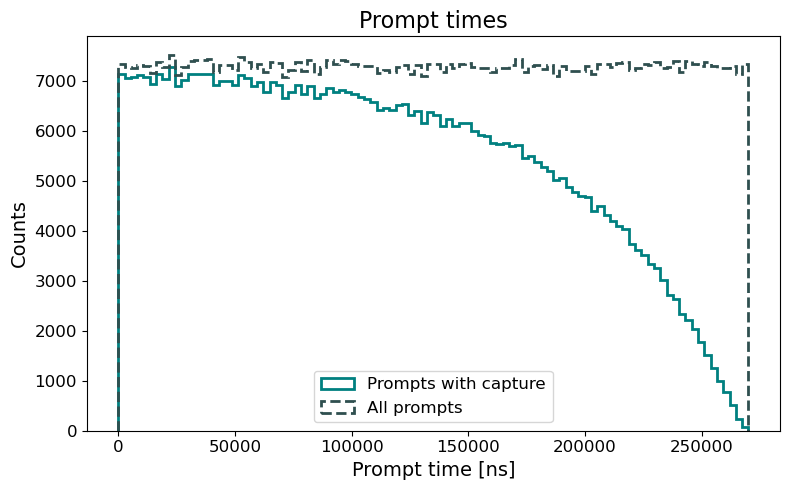

In [13]:
# Histogram of the prompt times

prompt_times = all_prompt_time
prompt_times_captures = np.concatenate([w for w in windows_df["prompt_time_withcapture"] if len(w) > 0]) if len(windows_df) else np.array([])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    prompt_times_captures,
    bins=100,
    range=(0, deltat_ns),
    label="Prompts with capture",
    color="teal",
    histtype="step",
    linewidth=2,
    linestyle="-",
)
ax.hist(
    prompt_times,
    bins=100,
    range=(0, deltat_ns),
    label="All prompts",
    color="darkslategray",
    histtype="step",
    linewidth=2,
    linestyle="--",
)
ax.set_xlabel("Prompt time [ns]", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.set_title("Prompt times", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

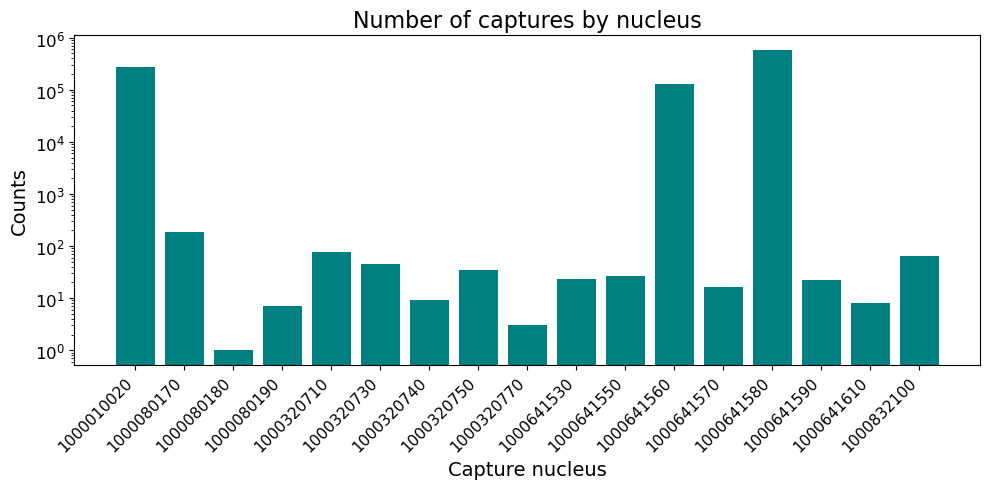

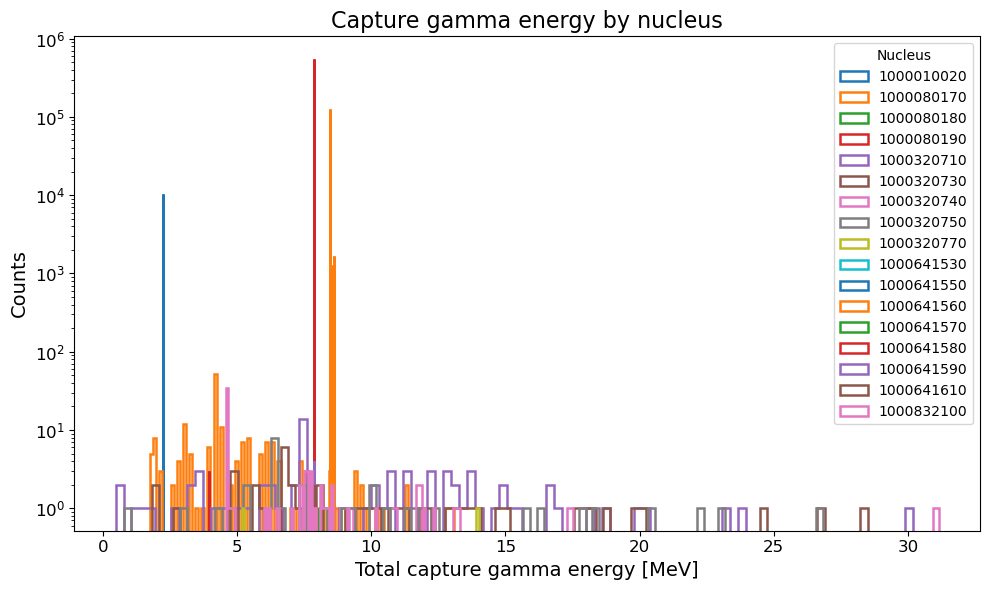

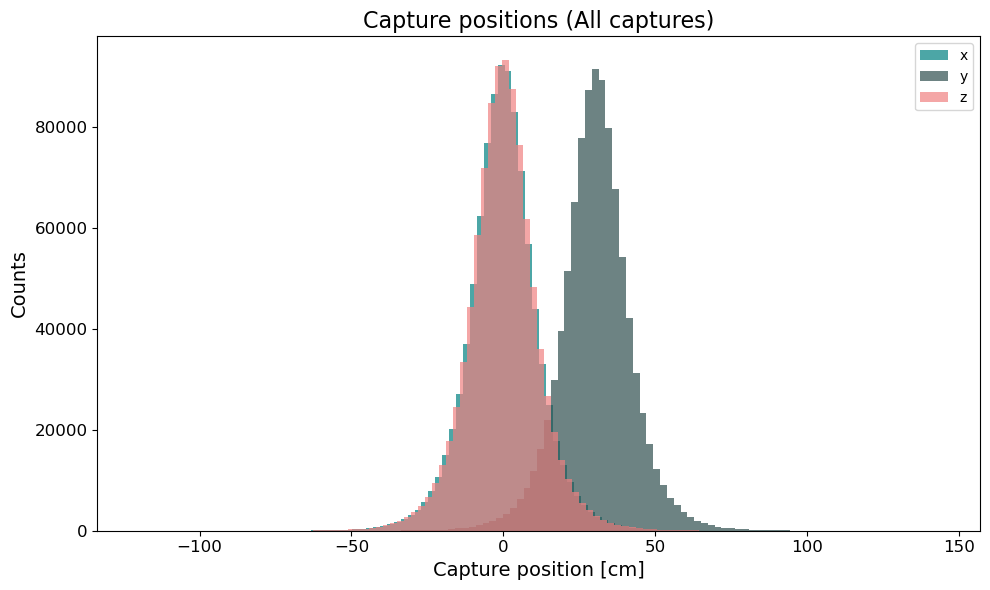

Unique capture nuclei: [1000010020 1000080170 1000080180 1000080190 1000320710 1000320730
 1000320740 1000320750 1000320770 1000641530 1000641550 1000641560
 1000641570 1000641580 1000641590 1000641610 1000832100], counts: [274772    186      1      7     78     46      9     34      3     23
     27 129642     16 573185     22      8     64]
Percentage of captures per nucleus: [2.80917635e+01 1.90160133e-02 1.02236631e-04 7.15656415e-04
 7.97445720e-03 4.70288502e-03 9.20129677e-04 3.47604545e-03
 3.06709892e-04 2.35144251e-03 2.76038903e-03 1.32541613e+01
 1.63578609e-03 5.86005032e+01 2.24920588e-03 8.17893046e-04
 6.54314437e-03]


In [14]:
# ---------------------------------
# Flatten capture info
# ---------------------------------
all_capture_nucleus = (
    np.concatenate([w for w in windows_df["capture_nucleus"] if len(w) > 0])
    if len(windows_df) else np.array([])
)

all_capture_x = (
    np.concatenate([w for w in windows_df["capture_x"] if len(w) > 0])
    if len(windows_df) else np.array([])
)
all_capture_y = (
    np.concatenate([w for w in windows_df["capture_y"] if len(w) > 0])
    if len(windows_df) else np.array([])
)
all_capture_z = (
    np.concatenate([w for w in windows_df["capture_z"] if len(w) > 0])
    if len(windows_df) else np.array([])
)

# Count captures per nucleus
unique_nuclei, counts_nuclei = np.unique(all_capture_nucleus, return_counts=True)

# ---------------------------------
# Choose nuclei to plot
# ---------------------------------
# Examples:
# selected_nuclei = None                    # all nuclei
# selected_nuclei = [1000010020]            # only H capture
# selected_nuclei = [1000641550, 1000641570] # some Gd isotopes

selected_nuclei = None   

if selected_nuclei is None:
    position_mask = np.ones_like(all_capture_nucleus, dtype=bool)
    selection_label = "All captures"
else:
    selected_nuclei = np.array(selected_nuclei)
    position_mask = np.isin(all_capture_nucleus, selected_nuclei)
    selection_label = ", ".join(str(n) for n in selected_nuclei)

# Filtered arrays
capture_x_sel = all_capture_x[position_mask]
capture_y_sel = all_capture_y[position_mask]
capture_z_sel = all_capture_z[position_mask]

# ---------------------------------
# 1) Histogram / bar plot of capture nucleus
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(len(unique_nuclei)), counts_nuclei, color="teal")
ax.set_xlabel("Capture nucleus", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.set_yscale("log")
ax.set_title("Number of captures by nucleus", fontsize=16)
ax.set_xticks(np.arange(len(unique_nuclei)))
ax.set_xticklabels([str(n) for n in unique_nuclei], rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", labelsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------
# 2) Total capture gamma energy split by nucleus
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

for nucleus in unique_nuclei:
    mask = all_capture_nucleus == nucleus
    ax.hist(
        all_capture_total_gammaE[mask],
        bins=100,
        histtype="step",
        linewidth=1.8,
        label=str(nucleus),
    )

ax.set_xlabel("Total capture gamma energy [MeV]", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.set_yscale("log")
ax.set_title("Capture gamma energy by nucleus", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(title="Nucleus", fontsize=10)
plt.tight_layout()
plt.show()

# ---------------------------------
# 3) Capture position, filtered by nucleus
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(capture_x_sel, bins=100, alpha=0.7, label="x", color="teal")
ax.hist(capture_y_sel, bins=100, alpha=0.7, label="y", color="darkslategray")
ax.hist(capture_z_sel, bins=100, alpha=0.7, label="z", color="lightcoral")

ax.set_xlabel("Capture position [cm]", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.set_title(f"Capture positions ({selection_label})", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Unique capture nuclei: {unique_nuclei}, counts: {counts_nuclei}")
print(f"Percentage of captures per nucleus: {counts_nuclei / counts_nuclei.sum() * 100}")
if selected_nuclei is not None:
    print(f"Selected nuclei: {selected_nuclei}")
    print(f"Number of selected captures: {position_mask.sum()}")

### ID List

- **1000010020** — **H-2 / deuterium**
- **1000010030** — **H-3 / tritium**
- **1000080170** — **O-17**
- **1000320710** — **Ge-71 (germanium-71)**
- **1000641530** — **Gd-153**
- **1000641550** — **Gd-155**
- **1000641560** — **Gd-156**
- **1000641570** — **Gd-157**
- **1000641580** — **Gd-158**
- **1000641590** — **Gd-159**
- **1000641610** — **Gd-161**
- **1000832100** — **Bi-210 (bismuth-210)**

---
---
---

Save the data back to a .root replicating real data format.

## Tree: `TData`

### Empty branches

* `window_time`
* `start_counter`
* `run_id`
* `sub_run_id`
* `spill_counter`
* `readout_number`
* `trigger_types`
* `trigger_times`
* `led_gains`
* `led_dacsettings`
* `led_ids`
* `led_card_ids`
* `led_slot_numbers`
* `led_event_types`
* `led_types`
* `led_sequence_numbers`
* `led_counters`
* `pmt_waveform_mpmt_card_ids`
* `pmt_waveform_pmt_channel_ids`
* `pmt_waveform_mpmt_slot_ids`
* `pmt_waveform_pmt_position_ids`
* `pmt_waveform_times`
* `pmt_waveforms`
* `beamline_pmt_qdc_charges`
* `beamline_pmt_tdc_times`
* `beamline_pmt_qdc_ids`
* `beamline_pmt_tdc_ids`

### Filled branches

* `event_number` ← `window_id`
* `hit_pmt_times` ← `hit_t`
* `hit_pmt_calibrated_times` ← `hit_t`
* `hit_pmt_charges` ← `photon_end_energy`
* `hit_mpmt_slot_ids` ← `mPMTid`
* `hit_pmt_position_ids` ← `mPMT_pmtid`
* `hit_mpmt_card_ids` ← same-length list as `hit_mpmt_slot_ids`, filled with `0`
* `hit_pmt_channel_ids`← same-length list as `hit_mpmt_slot_ids`, filled with `0`
* `hit_pmt_has_time_constant` ← same-length list as hits, filled with `1`


## Tree: `TTrueInfo`

* `event_number` ← `window_id`
* `n_overlay`
* `x`
* `y`
* `z`
* `dx`
* `dy`
* `dz`
* `hit_from_prompt`
* `hit_from_capture`
* `source_event_idx`
* `capture_t`
* `relative_capture_t`
* `prompt_time_withcapture`
* `prompt_time`
* `capture_x`
* `capture_y`
* `capture_z`
* `capture_nucleus`
* `capture_ngamma`
* `capture_total_gammaE`


In [ ]:
import awkward as ak

# ~ 5 mins to save a root file with 1000 windows with 25k events.

# ------------------------------------------------------------
# Output path
# ------------------------------------------------------------
output_root = Path("output/wcte_ambe_mc_data_0.root")
output_root.parent.mkdir(parents=True, exist_ok=True)

n_windows = len(windows_df)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def series_to_ak(series, dtype=None):
    """
    Convert a pandas Series whose entries are numpy arrays / lists
    into an Awkward jagged array, one list per window.
    """
    out = []
    for x in series:
        arr = np.asarray(x)
        if dtype is not None:
            arr = arr.astype(dtype, copy=False)
        out.append(arr)
    return ak.Array(out)


def empty_jagged(n, dtype):
    """
    Create an empty jagged branch with n entries, each entry = [].
    """
    return ak.Array([np.array([], dtype=dtype) for _ in range(n)])


def constant_like(series, value, dtype):
    """
    Create a jagged array with the same per-entry lengths as `series`,
    filled with a constant value.
    """
    out = []
    for x in series:
        arr = np.asarray(x)
        out.append(np.full(len(arr), value, dtype=dtype))
    return ak.Array(out)


# ------------------------------------------------------------
# Scalars for the "empty" scalar branches
# ------------------------------------------------------------
zeros_i32 = np.zeros(n_windows, dtype=np.int32)
zeros_i64 = np.zeros(n_windows, dtype=np.int64)
zeros_f64 = np.zeros(n_windows, dtype=np.float64)

event_number = windows_df["window_id"].to_numpy(dtype=np.int32)

# ------------------------------------------------------------
# Tree 1: WCTEReadoutWindows
# ------------------------------------------------------------
wcte_tree = {
    # Scalar branches that you want "empty" -> fill with zeros
    "window_time": zeros_i64,
    "start_counter": zeros_i64,
    "run_id": zeros_i32,
    "sub_run_id": zeros_i32,
    "spill_counter": zeros_i32,
    "event_number": event_number,
    "readout_number": zeros_i32,

    # Empty jagged branches
    "trigger_types": empty_jagged(n_windows, np.int32),
    "trigger_times": empty_jagged(n_windows, np.float64),
    "led_gains": empty_jagged(n_windows, np.float32),
    "led_dacsettings": empty_jagged(n_windows, np.int32),
    "led_ids": empty_jagged(n_windows, np.int32),
    "led_card_ids": empty_jagged(n_windows, np.int32),
    "led_slot_numbers": empty_jagged(n_windows, np.int32),
    "led_event_types": empty_jagged(n_windows, np.int32),
    "led_types": empty_jagged(n_windows, np.int32),
    "led_sequence_numbers": empty_jagged(n_windows, np.int32),
    "led_counters": empty_jagged(n_windows, np.int32),

    # Filled hit branches
    "hit_mpmt_card_ids": constant_like(windows_df["mPMTid"], 0, np.int32),
    "hit_pmt_channel_ids": constant_like(windows_df["mPMTid"], 0, np.int32),
    "hit_mpmt_slot_ids": series_to_ak(windows_df["mPMTid"], np.int32),
    "hit_pmt_position_ids": series_to_ak(windows_df["mPMT_pmtid"], np.int32),
    "hit_pmt_charges": series_to_ak(windows_df["photon_end_energy"], np.float32),
    "hit_pmt_times": series_to_ak(windows_df["hit_t"], np.float64),

    # Empty waveform branches
    "pmt_waveform_mpmt_card_ids": empty_jagged(n_windows, np.int32),
    "pmt_waveform_pmt_channel_ids": empty_jagged(n_windows, np.int32),
    "pmt_waveform_mpmt_slot_ids": empty_jagged(n_windows, np.int32),
    "pmt_waveform_pmt_position_ids": empty_jagged(n_windows, np.int32),
    "pmt_waveform_times": empty_jagged(n_windows, np.float64),
    "pmt_waveforms": empty_jagged(n_windows, np.float32),

    # Empty beamline branches
    "beamline_pmt_qdc_charges": empty_jagged(n_windows, np.float32),
    "beamline_pmt_tdc_times": empty_jagged(n_windows, np.float64),
    "beamline_pmt_qdc_ids": empty_jagged(n_windows, np.int32),
    "beamline_pmt_tdc_ids": empty_jagged(n_windows, np.int32),

    # Filled calibrated-time branches
    "hit_pmt_calibrated_times": series_to_ak(windows_df["hit_t"], np.float64),
    "hit_pmt_has_time_constant": constant_like(windows_df["mPMTid"], 1, np.int8),
}

# ------------------------------------------------------------
# Tree 2: TTrueInfo
# ------------------------------------------------------------
ttrue_tree = {
    "event_number": event_number,
    "n_overlay": windows_df["n_overlay"].to_numpy(dtype=np.int32),

    "x": series_to_ak(windows_df["x"], np.float32),
    "y": series_to_ak(windows_df["y"], np.float32),
    "z": series_to_ak(windows_df["z"], np.float32),

    "dx": series_to_ak(windows_df["dx"], np.float32),
    "dy": series_to_ak(windows_df["dy"], np.float32),
    "dz": series_to_ak(windows_df["dz"], np.float32),

    "hit_from_prompt": series_to_ak(windows_df["hit_from_prompt"], np.int32),
    "hit_from_capture": series_to_ak(windows_df["hit_from_capture"], np.int32),
    "source_event_idx": series_to_ak(windows_df["source_event_idx"], np.int32),

    "capture_t": series_to_ak(windows_df["capture_t"], np.float64),
    "relative_capture_t": series_to_ak(windows_df["relative_capture_t"], np.float64),
    "prompt_time_withcapture": series_to_ak(windows_df["prompt_time_withcapture"], np.float64),
    "prompt_time": series_to_ak(windows_df["prompt_time"], np.float64),

    "capture_x": series_to_ak(windows_df["capture_x"], np.float32),
    "capture_y": series_to_ak(windows_df["capture_y"], np.float32),
    "capture_z": series_to_ak(windows_df["capture_z"], np.float32),

    "capture_nucleus": series_to_ak(windows_df["capture_nucleus"], np.int32),
    "capture_ngamma": series_to_ak(windows_df["capture_ngamma"], np.int32),
    "capture_total_gammaE": series_to_ak(windows_df["capture_total_gammaE"], np.float32),
}

# ------------------------------------------------------------
# Write the ROOT file
# ------------------------------------------------------------
with uproot.recreate(output_root) as f:
    f["WCTEReadoutWindows"] = wcte_tree
    f["TTrueInfo"] = ttrue_tree

print(f"Wrote: {output_root.resolve()}")
print(f"Number of windows written: {n_windows}")

In [ ]:
with uproot.open(output_root) as f:
    print("Top-level keys:")
    for k in f.keys():
        print("  ", k)

    for tree_name in ["WCTEReadoutWindows", "TTrueInfo"]:
        tree = f[tree_name]
        print(f"\nTree: {tree_name}")
        print("Entries:", tree.num_entries)
        print("Branches:")
        for b in tree.keys():
            print(" ", b)

In [ ]:
# TEST: read back the branches from the .root file and inspect them

tree_name = "WCTEReadoutWindows"

with uproot.open(output_root) as f:
    tree = f[tree_name]
    branch_names = tree.keys()
    all_branches = tree.arrays(branch_names, library="ak")

In [ ]:
print("hit_mpmt_slot_ids: ", all_branches["hit_mpmt_slot_ids"][0])
print("hit_mpmt_card_ids: ", all_branches["hit_mpmt_card_ids"][0])
print("hit_pmt_position_ids: ", all_branches["hit_pmt_position_ids"][0])
print("hit_pmt_channel_ids: ", all_branches["hit_pmt_channel_ids"][0])


print("len(hit_pmt_times): ", len(all_branches["hit_pmt_times"][0]))
print("hit_calibrated_times: ", all_branches["hit_pmt_calibrated_times"][0])

---
---
---
---
---

# Efficiency calculation of the DAQ

How many of the neutron captures are lost because they fell outside the readout windows?

In [15]:
n_windows_total = len(windows_df)

# Total number of events
n_events = windows_df["n_overlay"].sum()

# Total number of captures before windowing, from the original events
n_captures_initial = np.sum(arr["ncaptures"][:n_events])

# Number of windows with at least one recorded capture
n_windows_with_capture = np.sum(windows_df["capture_t"].apply(len) > 0)

# Total number of recorded captures across all windows
n_captures_windowed = np.sum(windows_df["capture_t"].apply(len))

# Ratio
ratio_captures_to_events = n_captures_windowed / n_events
ratio_windowed_to_initial = n_captures_windowed / n_captures_initial

print(f"n_events: {n_events}")

print(f"Total number of windows: {n_windows_total}")
print(f"Windows with at least one recorded capture: {n_windows_with_capture}")
print(f"Total captures before windowing: {n_captures_initial}")
print(f"Total recorded captures in all windows: {n_captures_windowed}")
print()
print(f"Ratio = total captures / total events = {ratio_captures_to_events:.6f}")
print(f"Ratio = total captures / total captures before windowing (efficiency of the DAQ) = {ratio_windowed_to_initial:.6f}")

n_events: 1026715
Total number of windows: 100000
Windows with at least one recorded capture: 99991
Total captures before windowing: 1005645
Total recorded captures in all windows: 978123

Ratio = total captures / total events = 0.952672
Ratio = total captures / total captures before windowing (efficiency of the DAQ) = 0.972632


# Mean and fit of the capture time

Mean relative capture time = 66735.951
Fitted tau = 64638.365 ± 92.076


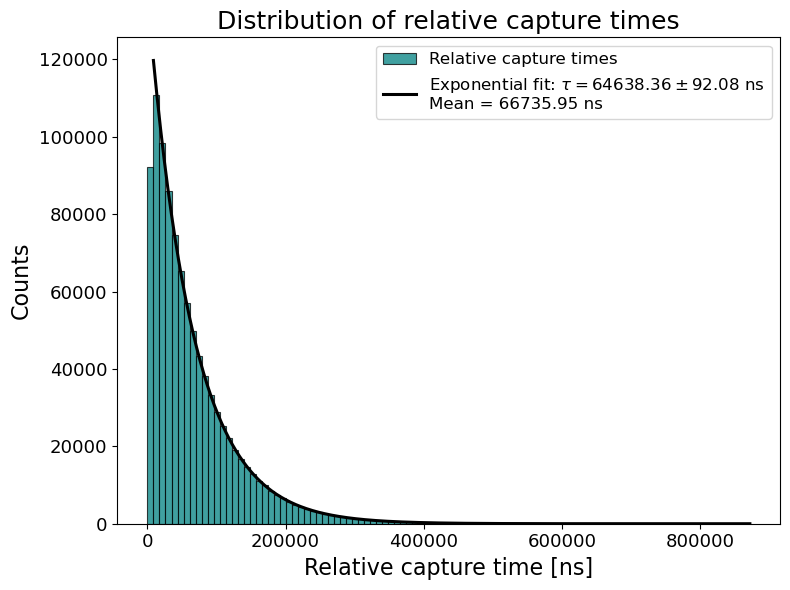

In [16]:
from scipy.optimize import curve_fit

# --- Prepare data ---
t = np.asarray(all_relative_capture_t, dtype=float)
t = t[np.isfinite(t)]
t = t[t >= 0]   # keep only physical capture times

# --- Summary statistics ---
mean_t = t.mean()
print(f"Mean relative capture time = {mean_t:.3f}")

# --- Histogram ---
nbins = 100
counts, bin_edges = np.histogram(t, bins=nbins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --- Exponential fit function ---
def expo_model(x, A, tau):
    return A * np.exp(-x / tau)

# Initial guesses
A0 = counts.max()
tau0 = mean_t if mean_t > 0 else 1.0

# Fit only nonzero bins, starting from the second bin
mask = (counts > 0)
mask[0] = False

popt, pcov = curve_fit(
    expo_model,
    bin_centers[mask],
    counts[mask],
    p0=[A0, tau0]
)

A_fit, tau_fit = popt
tau_err = np.sqrt(np.diag(pcov))[1]

print(f"Fitted tau = {tau_fit:.3f} ± {tau_err:.3f}")

# --- Smooth curve for plotting ---
xfit = np.linspace(bin_edges[1], bin_edges[-1], 500)
yfit = expo_model(xfit, A_fit, tau_fit)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.hist(
    t,
    bins=nbins,
    color="teal",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.8,
    label="Relative capture times"
)
plt.plot(
    xfit,
    yfit,
    color="black",
    linewidth=2.2,
    label=(
        fr"Exponential fit: $\tau = {tau_fit:.2f} \pm {tau_err:.2f}$ ns"
        "\n"
        fr"Mean = {mean_t:.2f} ns"
    )
)

plt.xlabel("Relative capture time [ns]", fontsize=16)
plt.ylabel("Counts", fontsize=16)
plt.title("Distribution of relative capture times", fontsize=18)
plt.tick_params(axis="both", labelsize=13)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

---
---
---

# DEBUG

In [ ]:
# Some prints
idx = 0
print("event =", arr["event"][idx], "subevent =", arr["subevent"][idx])
print("nhits =", arr["nhits"][idx], "ncaptures =", arr["ncaptures"][idx])
print("capture_t [ns] =", arr["capture_t"][idx])

print("True-hit times [ns] =", arr["truetime"][idx])
print("creation_process =", arr["creator_process"][idx])
print("hit_from_prompt =", arr["hit_from_prompt"][idx])
print("hit_from_capture =", arr["hit_from_capture"][idx])
print("hit_from_otherprocess =", arr["hit_from_otherprocess"][idx])

print("prompt description:")
print("  has_prompt =", arr["has_prompt"][idx])
print("  prompt_track_id =", arr["prompt_track_id"][idx])
print("  prompt_track_pdg =", arr["prompt_track_pdg"][idx])
print("  prompt_track_energy [MeV] =", arr["prompt_track_energy"][idx])
print("  prompt_track_time [ns] =", arr["prompt_track_time"][idx])
print("  prompt_track_creator_process =", arr["prompt_track_creator_process"][idx])


In [ ]:
mask_huge_hit_times = np.array([np.any(np.asarray(t) > 1e9) for t in arr["truetime"]])
print("Number of events with huge hit times:", mask_huge_hit_times.sum())
print("Indices of events with huge hit times:", np.where(mask_huge_hit_times))
#print("hits with truetime > 1e10 ns (should be 0):", arr["truetime"][mask_huge_hit_times])

In [ ]:
# Print the first 100 events where the first true photon arrives before the first capture
n_printed = 0

for idx in range(len(arr["event"])):
    truetime = arr["truetime"][idx]
    capture_t = arr["capture_t"][idx]

    if len(truetime) == 0 or len(capture_t) == 0:
        continue

    first_photon_t = truetime[0]
    first_capture_t = np.min(capture_t)

    if first_photon_t >= first_capture_t:
        continue

    if first_photon_t < first_capture_t and first_photon_t > 100:
        print("event =", arr["event"][idx], "subevent =", arr["subevent"][idx])
        print("nhits =", arr["nhits"][idx], "ncaptures =", arr["ncaptures"][idx])
        print("True-hit times [ns] =", arr["truetime"][idx])
        print("capture_t [ns] =", arr["capture_t"][idx])
        print("creator_process =", arr["creator_process"][idx])
        print('--------------------------------')

    n_printed += 1
    if n_printed == 100:
        break

# Absolute minimum capture time across all library events and its source event index
all_capture_t = np.concatenate([ct for ct in arr["capture_t"] if len(ct) > 0])
all_capture_event_idx = np.concatenate([
    np.full(len(ct), idx, dtype=np.int32)
    for idx, ct in enumerate(arr["capture_t"])
    if len(ct) > 0
])
if all_capture_t.size > 0:
    min_pos = np.argmin(all_capture_t)
    min_capture_t = all_capture_t[min_pos]
    min_event_idx = all_capture_event_idx[min_pos]
    print("Absolute min capture_t [ns] =", min_capture_t)
    print("Event index containing min capture_t =", min_event_idx)
    print("Event id =", arr["event"][min_event_idx], "subevent =", arr["subevent"][min_event_idx])
else:
    print("No capture times available in the library.")

In [ ]:
# Locate one specific event in the library from the window it belongs to, and print its info
n_windows = 10

# Sum of the events in the first n windows
n_events= np.sum(windows_df['n_overlay'][:n_windows])
print(f"Sum of n_overlay in the first {n_windows} windows = {n_events}")

# Index of the desired event inside the window
idx_w = 11

#Index of the desired event inside the library
idx = n_events + idx_w

print(f"Has prompts =", arr["has_prompt"][idx])
print("event =", arr["event"][idx], "subevent =", arr["subevent"][idx])
print("nhits =", arr["nhits"][idx], "ncaptures =", arr["ncaptures"][idx])
print("True-hit times [ns] =", arr["truetime"][idx])
print("capture_t [ns] =", arr["capture_t"][idx])

### Creation processes
| Index | Process                            |
| ----: | ---------------------------------- |
|     0 | `kUnknownProcess`                  |
|     1 | `kDarkNoise`                       |
|     2 | `kHadElastic`                      |
|     3 | `kNCapture`                        |
|     4 | `kCompt`                           |
|     5 | `kPhot`                            |
|     6 | `kCCerenkov`                       |
|     7 | `kSScintillation`                  |
|     8 | `kEBrem`                           |
|     9 | `kAnnihil`                         |
|    10 | `kConv`                            |
|    11 | `kEIoni`                           |
|    12 | `kNeutronInelastic`                |
|    13 | `kMuMinusCaptureAtRest`            |
|    14 | `kMuIoni`                          |
|    15 | `kHIoni`                           |
|    16 | `kDecay`                           |
|    17 | `kRadioactiveDecay`                |
|    18 | `kPhotonNuclear`                   |
|    19 | `kElectronNuclear`                 |
|    20 | `kOpticalPhotonWavelengthShifting` |
|    21 | `kHBertiniCaptureAtRest`           |
|    22 | `kProtonInelastic`                 |
|    23 | `kMuonMinusAtomicCapture`          |
|    24 | `kHadronStoppingProcess`           |
|   ... | ...                                |
|    85 | `kOpMieHG`                         |
|    86 | `kOpAbsorption`                    |
|    87 | `kOpRayleigh`                      |
|    88 | `kOpRaman`                         |
|    89 | `kOpBoundaryProcess`               |
|   ... | ...                                |
|   117 | `kInitialParticle`                 |


---

In [ ]:
# This is an old implementation.
# Windows are generated one by one without keeping the generator state.
# This introduces a small bias: some decays drawn for a given window can be shifted before the window start,
# so they effectively belong to the previous window and distort the intended Poissonian decay process.


'''
def make_window(library, activity_bq, deltat_ns, rng, start_idx):
    """
    Build one synthetic acquisition window by overlaying Poisson-distributed
    numbers of library events, without replacement across windows.

    Parameters
    ----------
    library : dict of awkward arrays / numpy arrays
        Event library loaded from wcte_ambe_truehits.root
    activity_bq : float
        Source activity in Bq
    deltat_ns : float
        Acquisition window length in ns
    rng : numpy.random.Generator
        Random number generator
    start_idx : int
        First library event to use for this window

    Returns
    -------
    window_dict : dict
        Synthetic window content
    next_idx : int
        Next unread library event index
    """
    deltat_s = deltat_ns * 1e-9
    n_overlay = rng.poisson(activity_bq * deltat_s)

    n_events_available = len(library["event"])

    if n_overlay == 0:
        return {
            "n_overlay": 0,
            "window_sum_photon_end_energy": 0.0,
            "n_hits": 0,
            "hit_t": np.array([], dtype=float),
            "tubeid": np.array([], dtype=np.int32),
            "mPMTid": np.array([], dtype=np.int32),
            "mPMT_pmtid": np.array([], dtype=np.int32),
            "x": np.array([], dtype=np.float32),
            "y": np.array([], dtype=np.float32),
            "z": np.array([], dtype=np.float32),
            "dx": np.array([], dtype=np.float32),
            "dy": np.array([], dtype=np.float32),
            "dz": np.array([], dtype=np.float32),
            "photon_end_energy": np.array([], dtype=np.float32),
            "creator_process": np.array([], dtype=np.int32),
            "hit_from_prompt": np.array([], dtype=np.int32),
            "hit_from_capture": np.array([], dtype=np.int32),
            "source_event_idx": np.array([], dtype=np.int32),
            "source_event": np.array([], dtype=np.int32),
            "source_subevent": np.array([], dtype=np.int32),
            "capture_t": np.array([], dtype=float),
            "relative_capture_t": np.array([], dtype=float),
            "prompt_time_withcapture": np.array([], dtype=float),
            "prompt_time": np.array([], dtype=float),
            "capture_x": np.array([], dtype=np.float32),
            "capture_y": np.array([], dtype=np.float32),
            "capture_z": np.array([], dtype=np.float32),
            "capture_nucleus": np.array([], dtype=np.int32),
            "capture_ngamma": np.array([], dtype=np.int32),
            "capture_total_gammaE": np.array([], dtype=np.float32),
        }, start_idx

    end_idx = start_idx + n_overlay
    if end_idx > n_events_available:
        raise ValueError(
            f"Not enough events left in library: requested {n_overlay} starting at {start_idx}, "
            f"but library size is {n_events_available}."
        )

    chosen = np.arange(start_idx, end_idx, dtype=np.int32)

    all_hit_t = []
    all_tubeid = []
    all_mPMTid = []
    all_mPMT_pmtid = []
    all_x = []
    all_y = []
    all_z = []
    all_dx = []
    all_dy = []
    all_dz = []
    all_photon_end_energy = []
    all_creator_process = []
    all_hit_from_prompt = []
    all_hit_from_capture = []
    all_source_event_idx = []
    all_source_event = []
    all_source_subevent = []

    all_capture_t = [] # capture time inside the window (after shifting)
    all_relative_capture_t = [] # capture time without shift = true capture time - prompt time
    all_prompt_time_withcapture = [] # prompt time for each capture that fell inside the window, but only for entries tagged as prompt in the extracted tree
    all_prompt_time = [] # all prompt times inside the window, one per prompt-tagged entry
    all_capture_x = []
    all_capture_y = []
    all_capture_z = []
    all_capture_nucleus = []
    all_capture_ngamma = []
    all_capture_total_gammaE = []

    for lib_idx in chosen:
        # One random offset per overlaid event
        # In order to avoid throwing away entire events, the negative capture time is taken as lower bound for the shift!

        #if len(library["capture_t"][lib_idx]) > 1:
        #    print(f"Warning: library event {lib_idx} has more than one capture time.")

        capture_t_lib_idx = library["capture_t"][lib_idx]
        ref = capture_t_lib_idx[0] if len(capture_t_lib_idx) > 0 else 0.0

        t0 = rng.uniform(-ref, deltat_ns) # start the shift in a negative number to account for captures coming from prompts that happened before the start of the window
        #t0 = 0.0  # No time shift for debugging

        t_shifted = library["truetime"][lib_idx] + t0
        keep = (t_shifted >= 0.0) & (t_shifted <= deltat_ns)

        if np.any(keep):
            all_hit_t.append(t_shifted[keep])
            all_tubeid.append(library["tubeid"][lib_idx][keep])
            all_mPMTid.append(library["mPMTid"][lib_idx][keep])
            all_mPMT_pmtid.append(library["mPMT_pmtid"][lib_idx][keep])
            all_x.append(library["x"][lib_idx][keep])
            all_y.append(library["y"][lib_idx][keep])
            all_z.append(library["z"][lib_idx][keep])
            all_dx.append(library["dx"][lib_idx][keep])
            all_dy.append(library["dy"][lib_idx][keep])
            all_dz.append(library["dz"][lib_idx][keep])
            all_photon_end_energy.append(library["photon_end_energy"][lib_idx][keep])
            all_creator_process.append(library["creator_process"][lib_idx][keep])
            all_hit_from_prompt.append(library["hit_from_prompt"][lib_idx][keep])
            all_hit_from_capture.append(library["hit_from_capture"][lib_idx][keep])

            n_kept = int(np.count_nonzero(keep))
            all_source_event_idx.append(np.full(n_kept, lib_idx, dtype=np.int32))
            all_source_event.append(np.full(n_kept, library["event"][lib_idx], dtype=np.int32))
            all_source_subevent.append(np.full(n_kept, library["subevent"][lib_idx], dtype=np.int32))

        # Prompt time using the explicit prompt tag and truth prompt-track.
        
        # This is handled independently of whether the entry has captures,
        # because prompt-only entries can exist in the library and should still
        # contribute to prompt_time if the shifted prompt falls inside the window.
        if int(library["has_prompt"][lib_idx]) == 1:
            prompt_t_relative = float(library["prompt_track_time"][lib_idx]) # truth prompt time inside the event (before shifting) (always 0)
            prompt_t = prompt_t_relative + t0 # truth prompt time inside the window (after shifting)

            # keep prompt only if it falls inside the window
            prompt_keep_all = (prompt_t >= 0.0) & (prompt_t <= deltat_ns)

            if prompt_keep_all:
                all_prompt_time.append(np.array([prompt_t], dtype=float))

        # Shift capture truth by the same event offset
        if library["ncaptures"][lib_idx] > 0:
            cap_t_shifted = library["capture_t"][lib_idx] + t0
            cap_keep = (cap_t_shifted >= 0.0) & (cap_t_shifted <= deltat_ns)

            if np.any(cap_keep): # if the capture falls outside the window after shifting, it's ignored
                all_capture_t.append(cap_t_shifted[cap_keep])
                all_relative_capture_t.append(library["capture_t"][lib_idx][cap_keep]) # true capture time without shift (capture time - prompt time)

                # Prompt time for each capture
                if int(library["has_prompt"][lib_idx]) == 1:
                    prompt_t_relative = float(library["prompt_track_time"][lib_idx]) # truth prompt-track time inside the event (before shifting) (always 0)
                    prompt_t = prompt_t_relative + t0 # truth prompt-track time inside the window (after shifting)

                    # keep prompt only if:
                    # 1) entry is tagged as prompt
                    # 2) prompt happens inside the window
                    # 3) prompt is before the kept capture (this condition is basically not needed, always happens)
                    prompt_keep = (
                        (prompt_t >= 0.0)
                        & (prompt_t <= deltat_ns)
                        & (prompt_t_relative < library["capture_t"][lib_idx][cap_keep])
                    )

                    all_prompt_time_withcapture.append(
                        np.full(np.count_nonzero(prompt_keep), prompt_t, dtype=float)
                    ) # this is done in a "general" way, as one prompt could have multiple captures

                all_capture_x.append(library["capture_x"][lib_idx][cap_keep])
                all_capture_y.append(library["capture_y"][lib_idx][cap_keep])
                all_capture_z.append(library["capture_z"][lib_idx][cap_keep])
                all_capture_nucleus.append(library["capture_nucleus"][lib_idx][cap_keep])
                all_capture_ngamma.append(library["capture_ngamma"][lib_idx][cap_keep])
                all_capture_total_gammaE.append(library["capture_total_gammaE"][lib_idx][cap_keep])
            #print(f"Event {lib_idx}: all_capture_t length = {len(all_capture_t)}")  # Debug print

    def _cat(lst, dtype):
        if not lst:
            return np.array([], dtype=dtype)
        return np.concatenate(lst).astype(dtype, copy=False)

    hit_t = _cat(all_hit_t, float)
    tubeid = _cat(all_tubeid, np.int32)
    mPMTid = _cat(all_mPMTid, np.int32)
    mPMT_pmtid = _cat(all_mPMT_pmtid, np.int32)
    x = _cat(all_x, np.float32)
    y = _cat(all_y, np.float32)
    z = _cat(all_z, np.float32)
    dx = _cat(all_dx, np.float32)
    dy = _cat(all_dy, np.float32)
    dz = _cat(all_dz, np.float32)
    photon_end_energy = _cat(all_photon_end_energy, np.float32)
    creator_process = _cat(all_creator_process, np.int32)
    hit_from_prompt = _cat(all_hit_from_prompt, np.int32)
    hit_from_capture = _cat(all_hit_from_capture, np.int32)
    source_event_idx = _cat(all_source_event_idx, np.int32)
    source_event = _cat(all_source_event, np.int32)
    source_subevent = _cat(all_source_subevent, np.int32)

    capture_t = _cat(all_capture_t, float)
    relative_capture_t = _cat(all_relative_capture_t, float) # true capture time without shift (capture time - prompt time)
    prompt_time_withcapture = _cat(all_prompt_time_withcapture, float)
    prompt_time = _cat(all_prompt_time, float)
    capture_x = _cat(all_capture_x, np.float32)
    capture_y = _cat(all_capture_y, np.float32)
    capture_z = _cat(all_capture_z, np.float32)
    capture_nucleus = _cat(all_capture_nucleus, np.int32)
    capture_ngamma = _cat(all_capture_ngamma, np.int32)
    capture_total_gammaE = _cat(all_capture_total_gammaE, np.float32)

    # Sort merged hits by time
    if hit_t.size > 0:
        order = np.argsort(hit_t, kind="stable")
        hit_t = hit_t[order]
        tubeid = tubeid[order]
        mPMTid = mPMTid[order]
        mPMT_pmtid = mPMT_pmtid[order]
        x = x[order]
        y = y[order]
        z = z[order]
        dx = dx[order]
        dy = dy[order]
        dz = dz[order]
        photon_end_energy = photon_end_energy[order]
        creator_process = creator_process[order]
        hit_from_prompt = hit_from_prompt[order]
        hit_from_capture = hit_from_capture[order]
        source_event_idx = source_event_idx[order]
        source_event = source_event[order]
        source_subevent = source_subevent[order]

    return {
        "n_overlay": int(n_overlay),
        "window_sum_photon_end_energy": float(photon_end_energy.sum()) if photon_end_energy.size else 0.0,
        "n_hits": int(hit_t.size),
        "hit_t": hit_t,
        "tubeid": tubeid,
        "mPMTid": mPMTid,
        "mPMT_pmtid": mPMT_pmtid,
        "x": x,
        "y": y,
        "z": z,
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "photon_end_energy": photon_end_energy,
        "creator_process": creator_process,
        "hit_from_prompt": hit_from_prompt,
        "hit_from_capture": hit_from_capture,
        "source_event_idx": source_event_idx,
        "source_event": source_event,
        "source_subevent": source_subevent,
        "capture_t": capture_t,
        "relative_capture_t": relative_capture_t,
        "prompt_time_withcapture": prompt_time_withcapture,
        "prompt_time": prompt_time,
        "capture_x": capture_x,
        "capture_y": capture_y,
        "capture_z": capture_z,
        "capture_nucleus": capture_nucleus,
        "capture_ngamma": capture_ngamma,
        "capture_total_gammaE": capture_total_gammaE,
    }, end_idx

'''

In [ ]:
'''
# Generate many synthetic windows without replacement across windows
windows = []
next_idx = 0

for i in range(N_windows):
    w, next_idx = make_window(arr, A, deltat_ns, rng, start_idx=next_idx)
    w["window_id"] = i
    windows.append(w)
    if (i + 1) % 1000 == 0:
        print(f"Generated {i + 1} / {N_windows} windows...")

windows_df = pd.DataFrame(windows)
pd.set_option('display.max_columns', None)
windows_df.head()
'''
